In [23]:
import os
from dataclasses import dataclass, field

import f2py_build.fort_sc as fsc
import numpy as np

os.environ["OMP_NUM_THREADS"] = "64"
print(fsc.__doc__)

This module 'fort_sc' is auto-generated with f2py (version:1.26.4).
Functions:
Fortran 90/95 modules:
  hamiltonians_sympy --- compute_dos(),compute_free_energy().


In [24]:
print(fsc.hamiltonians_sympy.compute_dos.__doc__)

dos = compute_dos(n_k_points,n_k_points_refined,t_sigma,t_pi,lambda_soc,t_rashba,delta_tri,mu,g,mu_b,b,theta_b,phi_b,zeta,ir_number,xi,dos_energies,[n_xi,n_energy_points_dos])

Wrapper for ``compute_dos``.

Parameters
----------
n_k_points : input int
n_k_points_refined : input int
t_sigma : input float
t_pi : input float
lambda_soc : input float
t_rashba : input float
delta_tri : input float
mu : input float
g : input float
mu_b : input float
b : input float
theta_b : input float
phi_b : input float
zeta : input float
ir_number : input int
xi : input rank-1 array('D') with bounds (n_xi)
dos_energies : input rank-1 array('d') with bounds (n_energy_points_dos)

Other Parameters
----------------
n_xi : input int, optional
    Default: shape(xi, 0)
n_energy_points_dos : input int, optional
    Default: shape(dos_energies, 0)

Returns
-------
dos : rank-2 array('d') with bounds (n_energy_points_dos,24)



In [25]:
print(fsc.hamiltonians_sympy.compute_free_energy.__doc__)

free_energy = compute_free_energy(n_k_points,t_sigma,t_pi,lambda_soc,t_rashba,delta_tri,mu,g,mu_b,b,theta_b,phi_b,t,ir_number,xi,[n_xi])

Wrapper for ``compute_free_energy``.

Parameters
----------
n_k_points : input int
t_sigma : input float
t_pi : input float
lambda_soc : input float
t_rashba : input float
delta_tri : input float
mu : input float
g : input float
mu_b : input float
b : input float
theta_b : input float
phi_b : input float
t : input float
ir_number : input int
xi : input rank-1 array('D') with bounds (n_xi)

Other Parameters
----------------
n_xi : input int, optional
    Default: shape(xi, 0)

Returns
-------
free_energy : float



In [26]:
@dataclass
class dispersion_parameters:
  """
  This dataclass defines parameters for a tight-binding model of transition metal oxide.
  All energies are defined in units of [meV].
  """

  t_sigma: np.float64 = np.float64(500)  # Energy of sigma-overlap between d orbitals [meV]
  t_pi: np.float64 = np.float64(40)  # Energy of pi-overlap between d orbitals [meV]
  l_soc: np.float64 = np.float64(-10)  # Atomic SOC energy [meV]
  t_rashba: np.float64 = np.float64(5)  # Odd-momentum (p-d hybridization) hopping energy [meV]
  d_tri: np.float64 = np.float64(10)  # Trigonal spitting energy [meV]
  mu: np.float64 = np.float64(0.0)  # Chemical potential [meV]
  a: np.float64 = np.float64(1.0)  # Lattice constant
  g: np.float64 = np.float64(2.0)  # Lande g-factor
  B: np.float64 = np.float64(0.0)  # Magnetic field magnitude [T]
  theta_B: np.float64 = np.float64(0.0)  # Angle between magnetic field and positive Z-axis in [111] direction [rad]
  phi_B: np.float64 = np.float64(0.0)  # Angle between magnetic field positive X-axis [rad]

  energy_unit: str = "(meV)"

  min_energy_kinetics: np.float64 = field(
    init=False
  )  # Minimum energy estimated from kinetic-only terms of the Hamiltonian [meV]
  mu_B: np.float64 = field(init=False)  # [meV/T]

  def __post_init__(self):
    self.min_energy_kinetics = np.float64(-(2 * self.t_sigma + self.t_pi))
    self.mu_B = np.float64(5.788381798218 * 1e-2)


params_sc = dispersion_parameters()  # default values
params_sc.mu = np.float64(0.95) * params_sc.min_energy_kinetics

In [27]:
import time

zeta = 5e-2
dos_energies = np.linspace(-10, 10, int(1e3))
ir_coeffs = np.array([np.complex128(0.0) for _ in range(19)])
ir_coeffs[1] = 1

start = time.monotonic_ns()
# dos = fsc.hamiltonians_sympy.compute_dos(10,
#                                          10,
#                                          params_sc.t_sigma,
#                                          params_sc.t_pi,
#                                          params_sc.l_soc,
#                                          params_sc.t_rashba,
#                                          params_sc.d_tri,
#                                          params_sc.mu,
#                                          params_sc.g,
#                                          params_sc.mu_B,
#                                          params_sc.B,
#                                          params_sc.theta_B,
#                                          params_sc.phi_B,
#                                          zeta,
#                                          1,
#                                          ir_coeffs,
#                                          dos_energies
#                                          )
end = time.monotonic_ns()
print(f"Elapsed {(end - start) * 1e-9} [s]")

Elapsed 2.3990000000000002e-05 [s]


In [28]:
import matplotlib.pyplot as plt
# plt.plot(dos_energies, dos)
# plt.plot(dos_energies, np.sum(dos, axis=1), color="black")
# plt.show()

In [29]:
from tqdm import tqdm

temperature = 0.1  # [K]
free_energies = []
durations = []
# Check convergence of free energy with integration density
k_points_table = [100, 200, 500, 800, 1000, 1500, 2000, 4000, 6000, 8000]
for n_points in tqdm(k_points_table):
  start = time.monotonic_ns() * 1e-9  # [s]
  free_energy = fsc.hamiltonians_sympy.compute_free_energy(
    n_points,
    params_sc.t_sigma,
    params_sc.t_pi,
    params_sc.l_soc,
    params_sc.t_rashba,
    params_sc.d_tri,
    params_sc.mu,
    params_sc.g,
    params_sc.mu_B,
    params_sc.B,
    params_sc.theta_B,
    params_sc.phi_B,
    temperature,
    1,
    ir_coeffs,
  )
  end = time.monotonic_ns() * 1e-9
  free_energies.append(free_energy)
  durations.append(end - start)

100%|██████████| 10/10 [18:10<00:00, 109.06s/it]


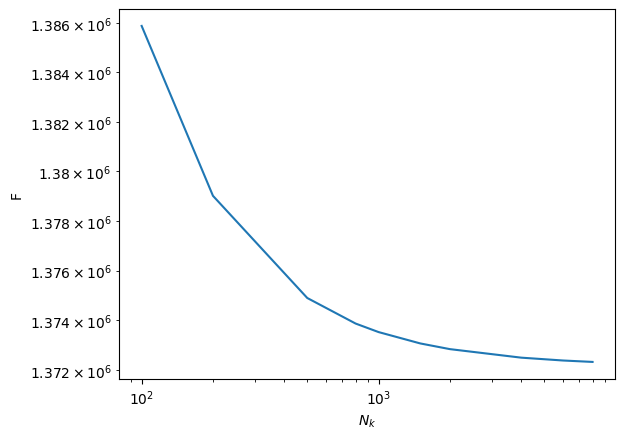

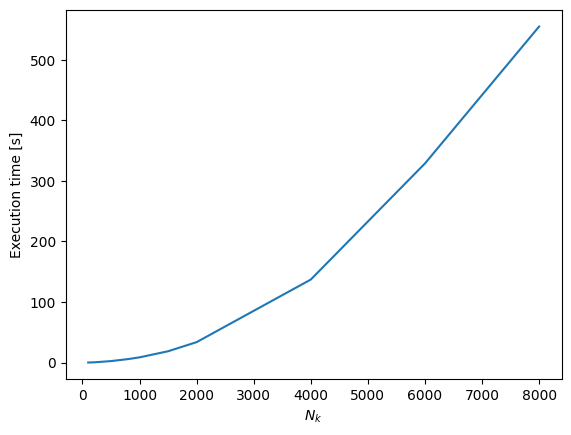

In [30]:
plt.plot(k_points_table, np.abs(free_energies))
plt.yscale("log")
plt.xscale("log")
plt.ylabel("F")
plt.xlabel(r"$N_k$")
plt.show()

plt.plot(k_points_table, durations)
plt.ylabel("Execution time [s]")
plt.xlabel(r"$N_k$")
plt.show()

In [31]:
free_energies = []
coeff_table = np.linspace(0, 5, 20)
for coeff in tqdm(coeff_table):
  free_energies_coeff = []
  for coeff_index in tqdm(range(len(ir_coeffs))):
    ir_coeffs[coeff_index] = coeff
    free_energy = fsc.hamiltonians_sympy.compute_free_energy(
      2000,
      params_sc.t_sigma,
      params_sc.t_pi,
      params_sc.l_soc,
      params_sc.t_rashba,
      params_sc.d_tri,
      params_sc.mu,
      params_sc.g,
      params_sc.mu_B,
      params_sc.B,
      params_sc.theta_B,
      params_sc.phi_B,
      temperature,
      1,
      ir_coeffs,
    )
    free_energies_coeff.append(free_energy)
  free_energies.append(free_energies_coeff)

100%|██████████| 20/20 [3:46:11<00:00, 678.57s/it]


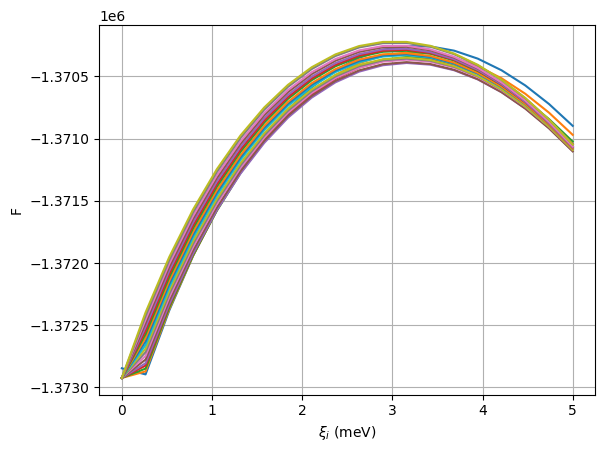

In [32]:
plt.plot(coeff_table, free_energies)
plt.xlabel(r"$\xi_i$ (meV)")
plt.ylabel("F")
plt.grid(True)
plt.show()

(20, 19)


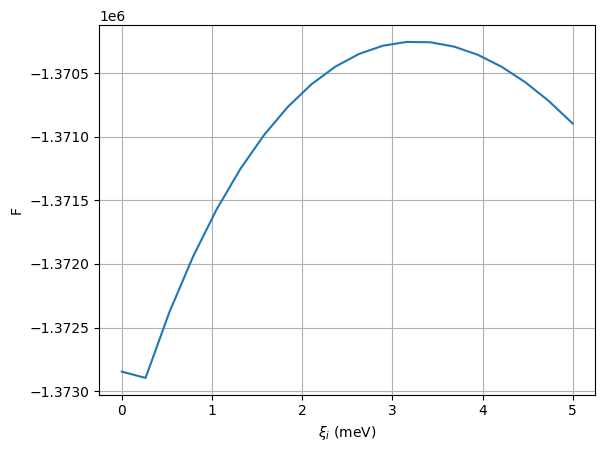

In [42]:
print(np.asarray(free_energies).shape)
free_energies_numpy = np.asarray(free_energies)
plt.plot(coeff_table, free_energies_numpy[:, 0])
plt.xlabel(r"$\xi_i$ (meV)")
plt.ylabel("F")
plt.grid(True)
plt.show()